# Esperimenti sul metodo di Montecarlo
L'obbiettivo è stimare l'area di una funzione generica in un intervallo definito $[a,b]$ utilizzando il metodo di Montecarlo.

$$
f: \mathbb{R} \rightarrow \mathbb{R} \\
\int_{a}^{b}{f(x) dx} \approx {A_{stimata}}
$$

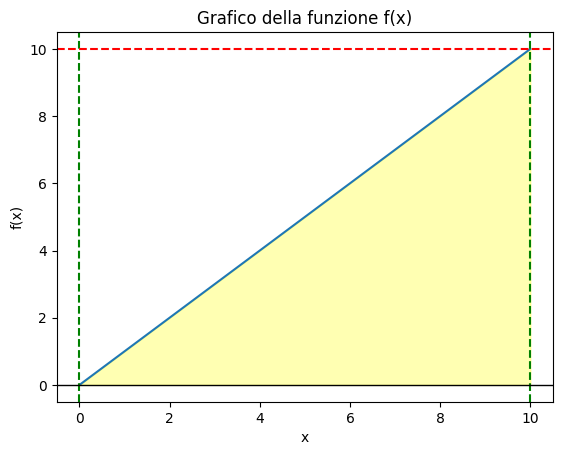

In [2]:
import matplotlib.pyplot as plt
import numpy as np

def f(x):
    return x

intervallo = (0, 10)
a, b = intervallo

x = np.linspace(a, b, 100)
y = [f(xi) for xi in x]

plt.plot(x, y, label="f(x)")
# Linee verticali agli estremi
plt.axvline(a, color="green", linestyle="--")
plt.axvline(b, color="green", linestyle="--")

# Linea orizzontale al massimo della funzione
plt.axhline(max(y), color="red", linestyle="--")
# Linea dello zero
plt.axhline(0, color="black", linewidth=1)

# Area sotto la funzione
plt.fill_between(x, y, 0, color="yellow", alpha=0.3)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Grafico della funzione f(x)")
plt.show()



In [3]:
import random

def genera_coordinate(n, range_x, range_y):
    return [
        (random.uniform(range_x[0], range_x[1]),
         random.uniform(range_y[0], range_y[1]))
        for _ in range(n)
    ]

def montecarlo_estimate(f,p):
    x, y = p
    return 0 if (f(x) < y) else 1

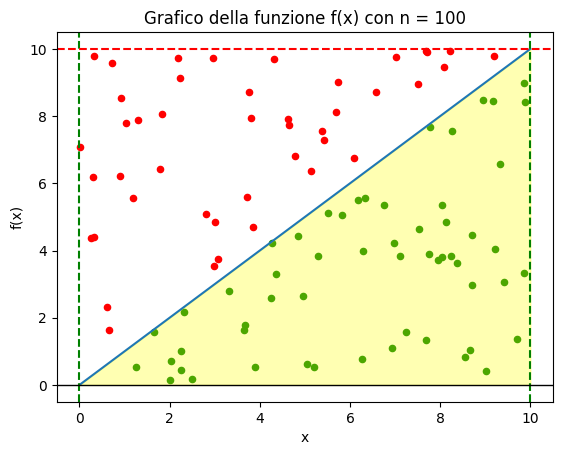

In [4]:
n = 100
point = genera_coordinate(n, intervallo, (0, max(y)))

stima = [montecarlo_estimate(f, coord)
         for coord in point]

# Estrai le coordinate x e y
xs = [p[0] for p in point]
ys = [p[1] for p in point]

# Scatter rosso per i punti con stima = 0
plt.scatter(
    [xs[i] for i in range(n) if stima[i] == 0],
    [ys[i] for i in range(n) if stima[i] == 0],
    color="red",
    s=20,
    label="stima = 0"
)

# Scatter verde per i punti con stima = 1
plt.scatter(
    [xs[i] for i in range(n) if stima[i] == 1],
    [ys[i] for i in range(n) if stima[i] == 1],
    color="green",
    s=20,
    label="stima = 1"
)
plt.plot(x, y, label="f(x)")
# Linee verticali agli estremi
plt.axvline(a, color="green", linestyle="--")
plt.axvline(b, color="green", linestyle="--")

# Linea orizzontale al massimo della funzione
plt.axhline(max(y), color="red", linestyle="--")
# Linea dello zero
plt.axhline(0, color="black", linewidth=1)

# Area sotto la funzione
plt.fill_between(x, y, 0, color="yellow", alpha=0.3)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Grafico della funzione f(x) con n = 100")
plt.show()


In [5]:
def estimate_area_from_experiment(area_totale, punti_totali, punti_in_area):
    return (area_totale * punti_in_area) / punti_totali

print(f"Area stimata: { estimate_area_from_experiment((b - a) * (max(y)), n, sum(stima))}")

def F(x):
    return (1/2)*(x**2) # integrale della funzione x

a,b = intervallo
print(f"Area calcolata su integrale: {F(b) - F(a)}")

Area stimata: 56.0
Area calcolata su integrale: 50.0


In [6]:
def montecarlo(f,intervallo, massimo, punti):
    a,b = intervallo
    return estimate_area_from_experiment(
       (b-a)*massimo,
       len(punti),
       sum([montecarlo_estimate(f, coord)
            for coord in punti])
    )

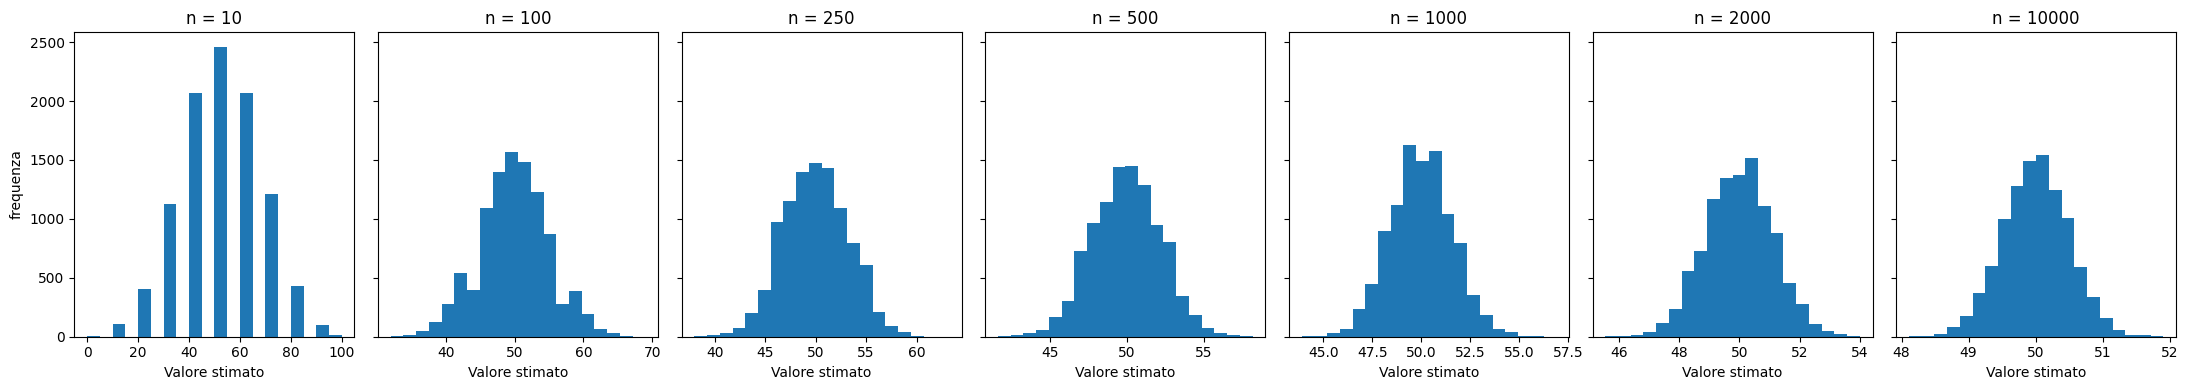

In [7]:
ns = [10, 100, 250, 500, 1000, 2000, 10000]

## METODO SPERIMENTALE, NON EFFICIENTE

solutions = []
for n in ns:
    experiment = []
    for _ in np.arange(0, 10000, 1):
        p = genera_coordinate(n,intervallo, (0,f(b)))
        experiment.append(montecarlo(f,intervallo, f(b), p))
    solutions.append(experiment)

fig, axes = plt.subplots(1, 7, figsize=(22, 4), sharey=True)

for i in range(7):
    axes[i].hist(solutions[i], bins = 20)
    axes[i].set_title(f"n = {ns[i]}")
    axes[i].set_xlabel("Valore stimato")
    if i == 0:
        axes[i].set_ylabel("frequenza")

plt.tight_layout()
plt.show()


In [8]:
import pandas as pd
df = pd.DataFrame()
for i in np.arange(0,len(ns), 1):
    df[f"N_points:{ns[i]}"] = solutions[i]

#df.to_csv("montecarloLinear.csv")

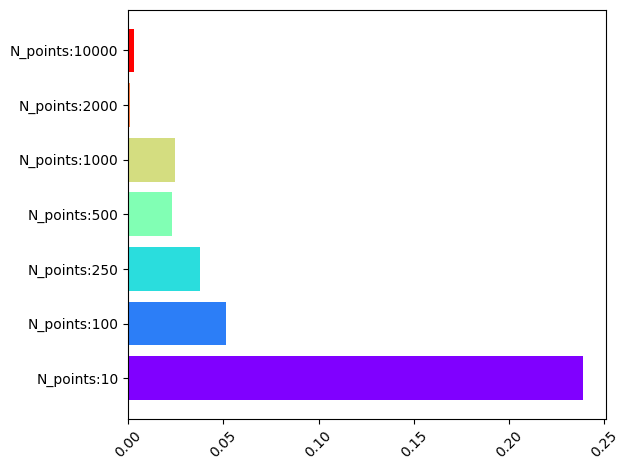

In [9]:
true_area = F(b) - F(a)

bias = (df.mean() - true_area)
colors = plt.cm.rainbow(np.linspace(0, 1, len(bias)))

plt.barh(bias.index, abs(bias.values), color=colors)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Esperimento di stima di PI utilizzando il metodo Montecarlo

L'equazione che descrive un circonferenza con origine negli assi è:
$$
x^2 + y^2 = r^2
$$
se fissiamo $r = 1$ allora:
$$
x^2 + y^2 = 1 \\
y^2 = 1 - (x^2) \\
\sqrt{y^2} = \sqrt{1 - (x^2)}

$$

prendiamo in considerazione solamente il primo quadrante in un intervallo da 0 a 1 per il metodo di montecarlo

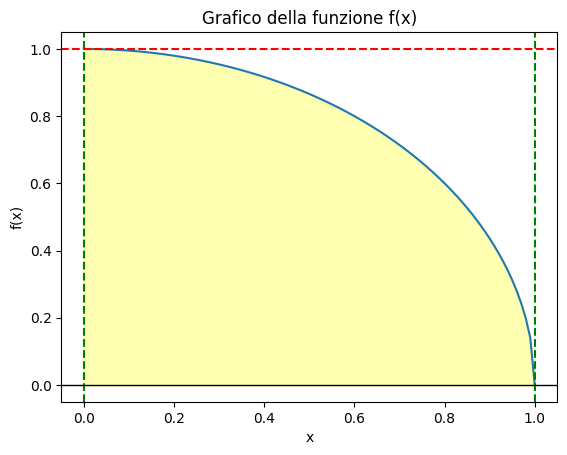

In [10]:
 # redefinizione di f(x)
import math
def f(x):
    # definita tra 0 e r
    return math.sqrt(1-(x**2))

intervallo = (0,1)
a,b = intervallo

x = np.arange(a, b+0.01, 0.01)
y = [f(xi) for xi in x]

plt.plot(x, y, label="f(x)")
# Linee verticali agli estremi
plt.axvline(a, color="green", linestyle="--")
plt.axvline(b, color="green", linestyle="--")

# Linea orizzontale al massimo della funzione
plt.axhline(max(y), color="red", linestyle="--")
# Linea dello zero
plt.axhline(0, color="black", linewidth=1)

# Area sotto la funzione
plt.fill_between(x, y, 0, color="yellow", alpha=0.3)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Grafico della funzione f(x)")
plt.show()


In [11]:
punti = genera_coordinate(10000, intervallo, (0,1))
#df = pd.DataFrame(punti)
#df = pd.read_csv("punti.csv")
#punti = (df.x, df.y)

In [12]:
pi = (montecarlo(f, intervallo, 1, punti ) *4)
print(pi)

3.124


In [13]:
print(pi - math.pi)

-0.017592653589793006


In [25]:
def m_sim(tot_punti, f):
    int_punti = 0
    i = 0
    while i < tot_punti:
        int_punti += m_experiment(f)
        i+=1
    return int_punti

def m_experiment(f):
    x = random.uniform(0,1)
    y = random.uniform(0,1)
    return montecarlo_estimate(f,(x,y))


In [ ]:
n = 1000000000000

estimate_area_from_experiment(1,n,m_sim(n,f))*4